In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Styling — makes plots look professional
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.size'] = 11

df = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# ── Basic audit ──────────────────────────────────────────────
print(f"Shape: {df.shape}")
print(f"\nColumn dtypes:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
print(f"\nDuplicates: {df.duplicated().sum()}")
df.describe()

Shape: (7043, 21)

Column dtypes:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing values:
Series([], dtype: int64)

Duplicates: 0


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [2]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# These 11 rows are customers with tenure=0 (just joined, no charges yet)
print(df[df['TotalCharges'].isna()][['tenure', 'MonthlyCharges', 'TotalCharges']])

# Fill with 0 — they have no charges yet, this is correct
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Convert target to binary
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df.drop(columns=['customerID'], inplace=True)  # not a feature

      tenure  MonthlyCharges  TotalCharges
488        0           52.55           NaN
753        0           20.25           NaN
936        0           80.85           NaN
1082       0           25.75           NaN
1340       0           56.05           NaN
3331       0           19.85           NaN
3826       0           25.35           NaN
4380       0           20.00           NaN
5218       0           19.70           NaN
6670       0           73.35           NaN
6754       0           61.90           NaN


Overall churn rate: 26.5%


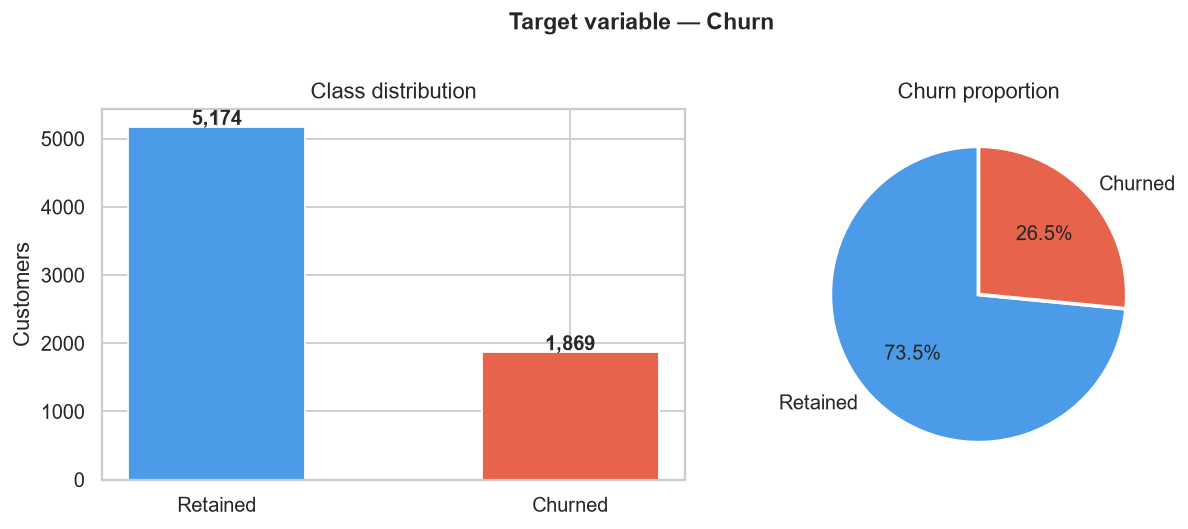

In [3]:
churn_rate = df['Churn'].mean()
print(f"Overall churn rate: {churn_rate:.1%}")  # ~26.5%

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Count plot
counts = df['Churn'].value_counts()
axes[0].bar(['Retained', 'Churned'], counts, color=['#4C9BE8', '#E8634C'], width=0.5)
axes[0].set_title('Class distribution')
axes[0].set_ylabel('Customers')
for i, v in enumerate(counts):
    axes[0].text(i, v + 30, f'{v:,}', ha='center', fontweight='bold')

# Pie
axes[1].pie(counts, labels=['Retained', 'Churned'],
            colors=['#4C9BE8', '#E8634C'],
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Churn proportion')

plt.suptitle('Target variable — Churn', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../reports/figures/01_churn_distribution.png', bbox_inches='tight')
plt.show()

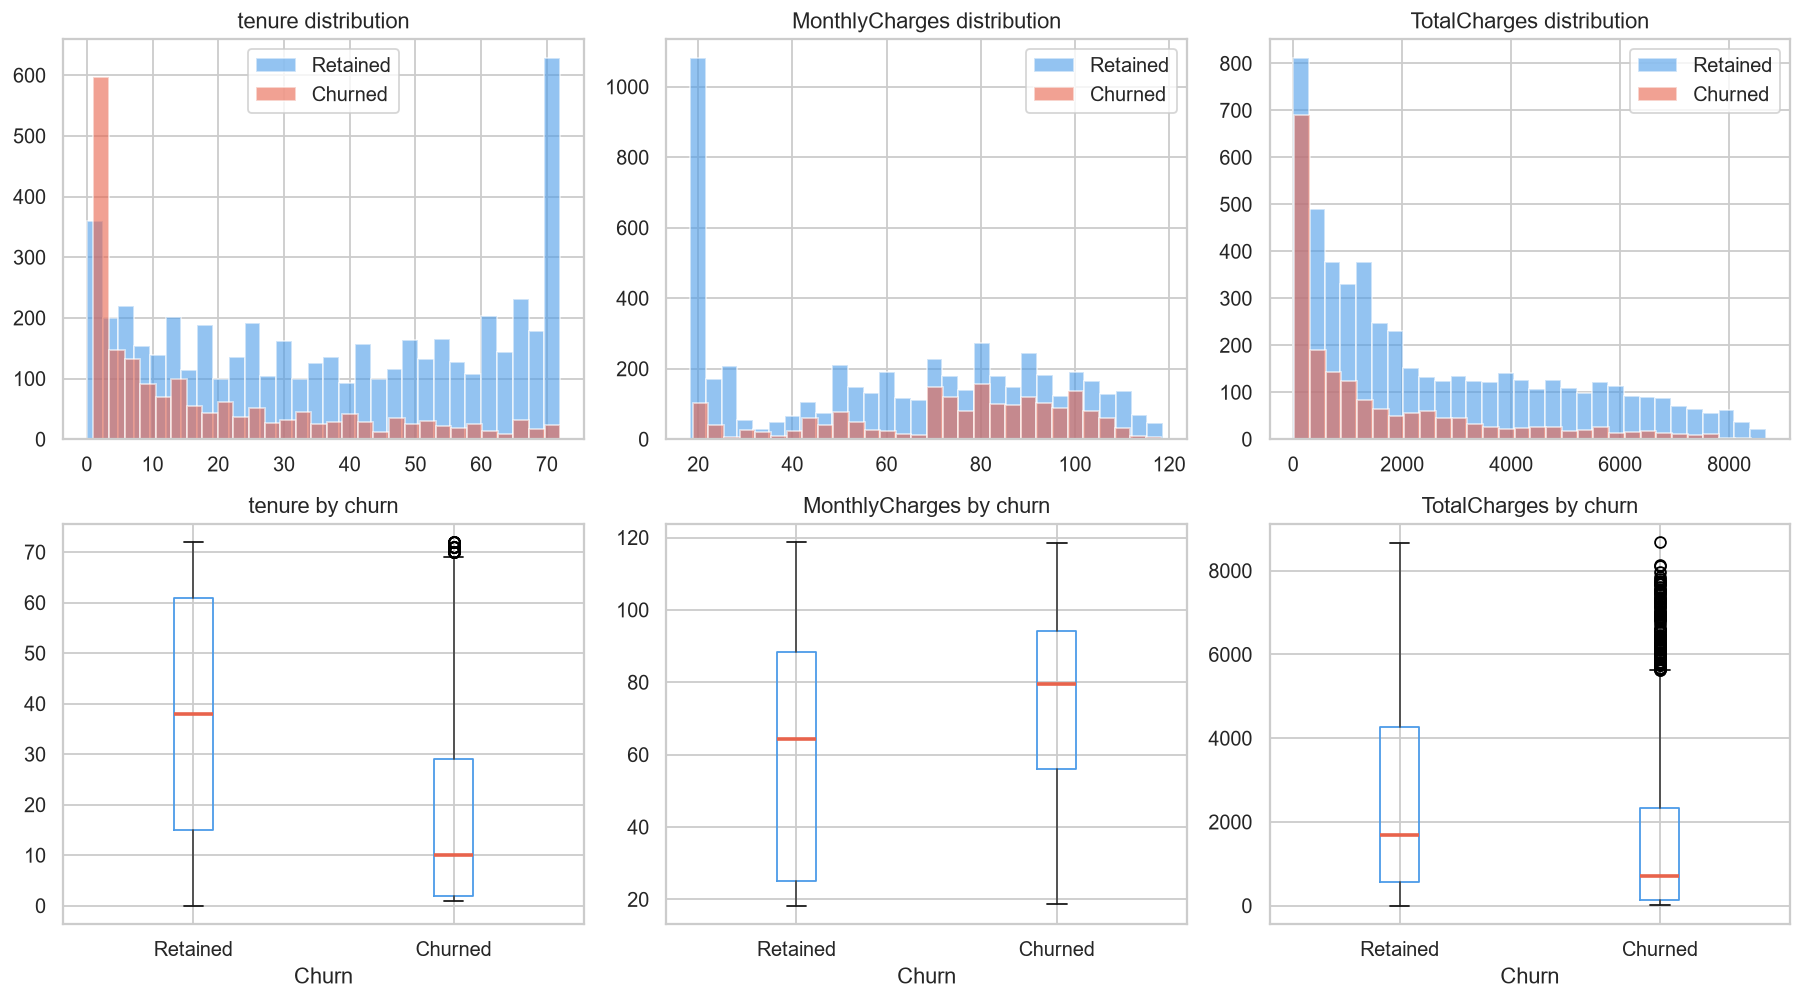

In [4]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for i, col in enumerate(num_cols):
    # Distribution by churn
    for churn_val, label, color in [(0, 'Retained', '#4C9BE8'), (1, 'Churned', '#E8634C')]:
        axes[0, i].hist(df[df['Churn'] == churn_val][col],
                        bins=30, alpha=0.6, label=label, color=color, edgecolor='white')
    axes[0, i].set_title(f'{col} distribution')
    axes[0, i].legend()

    # Boxplot
    df.boxplot(column=col, by='Churn', ax=axes[1, i],
               boxprops=dict(color='#4C9BE8'),
               medianprops=dict(color='#E8634C', linewidth=2))
    axes[1, i].set_title(f'{col} by churn')
    axes[1, i].set_xticklabels(['Retained', 'Churned'])

plt.suptitle('')
plt.tight_layout()
plt.savefig('../reports/figures/02_numerical_distributions.png', bbox_inches='tight')
plt.show()

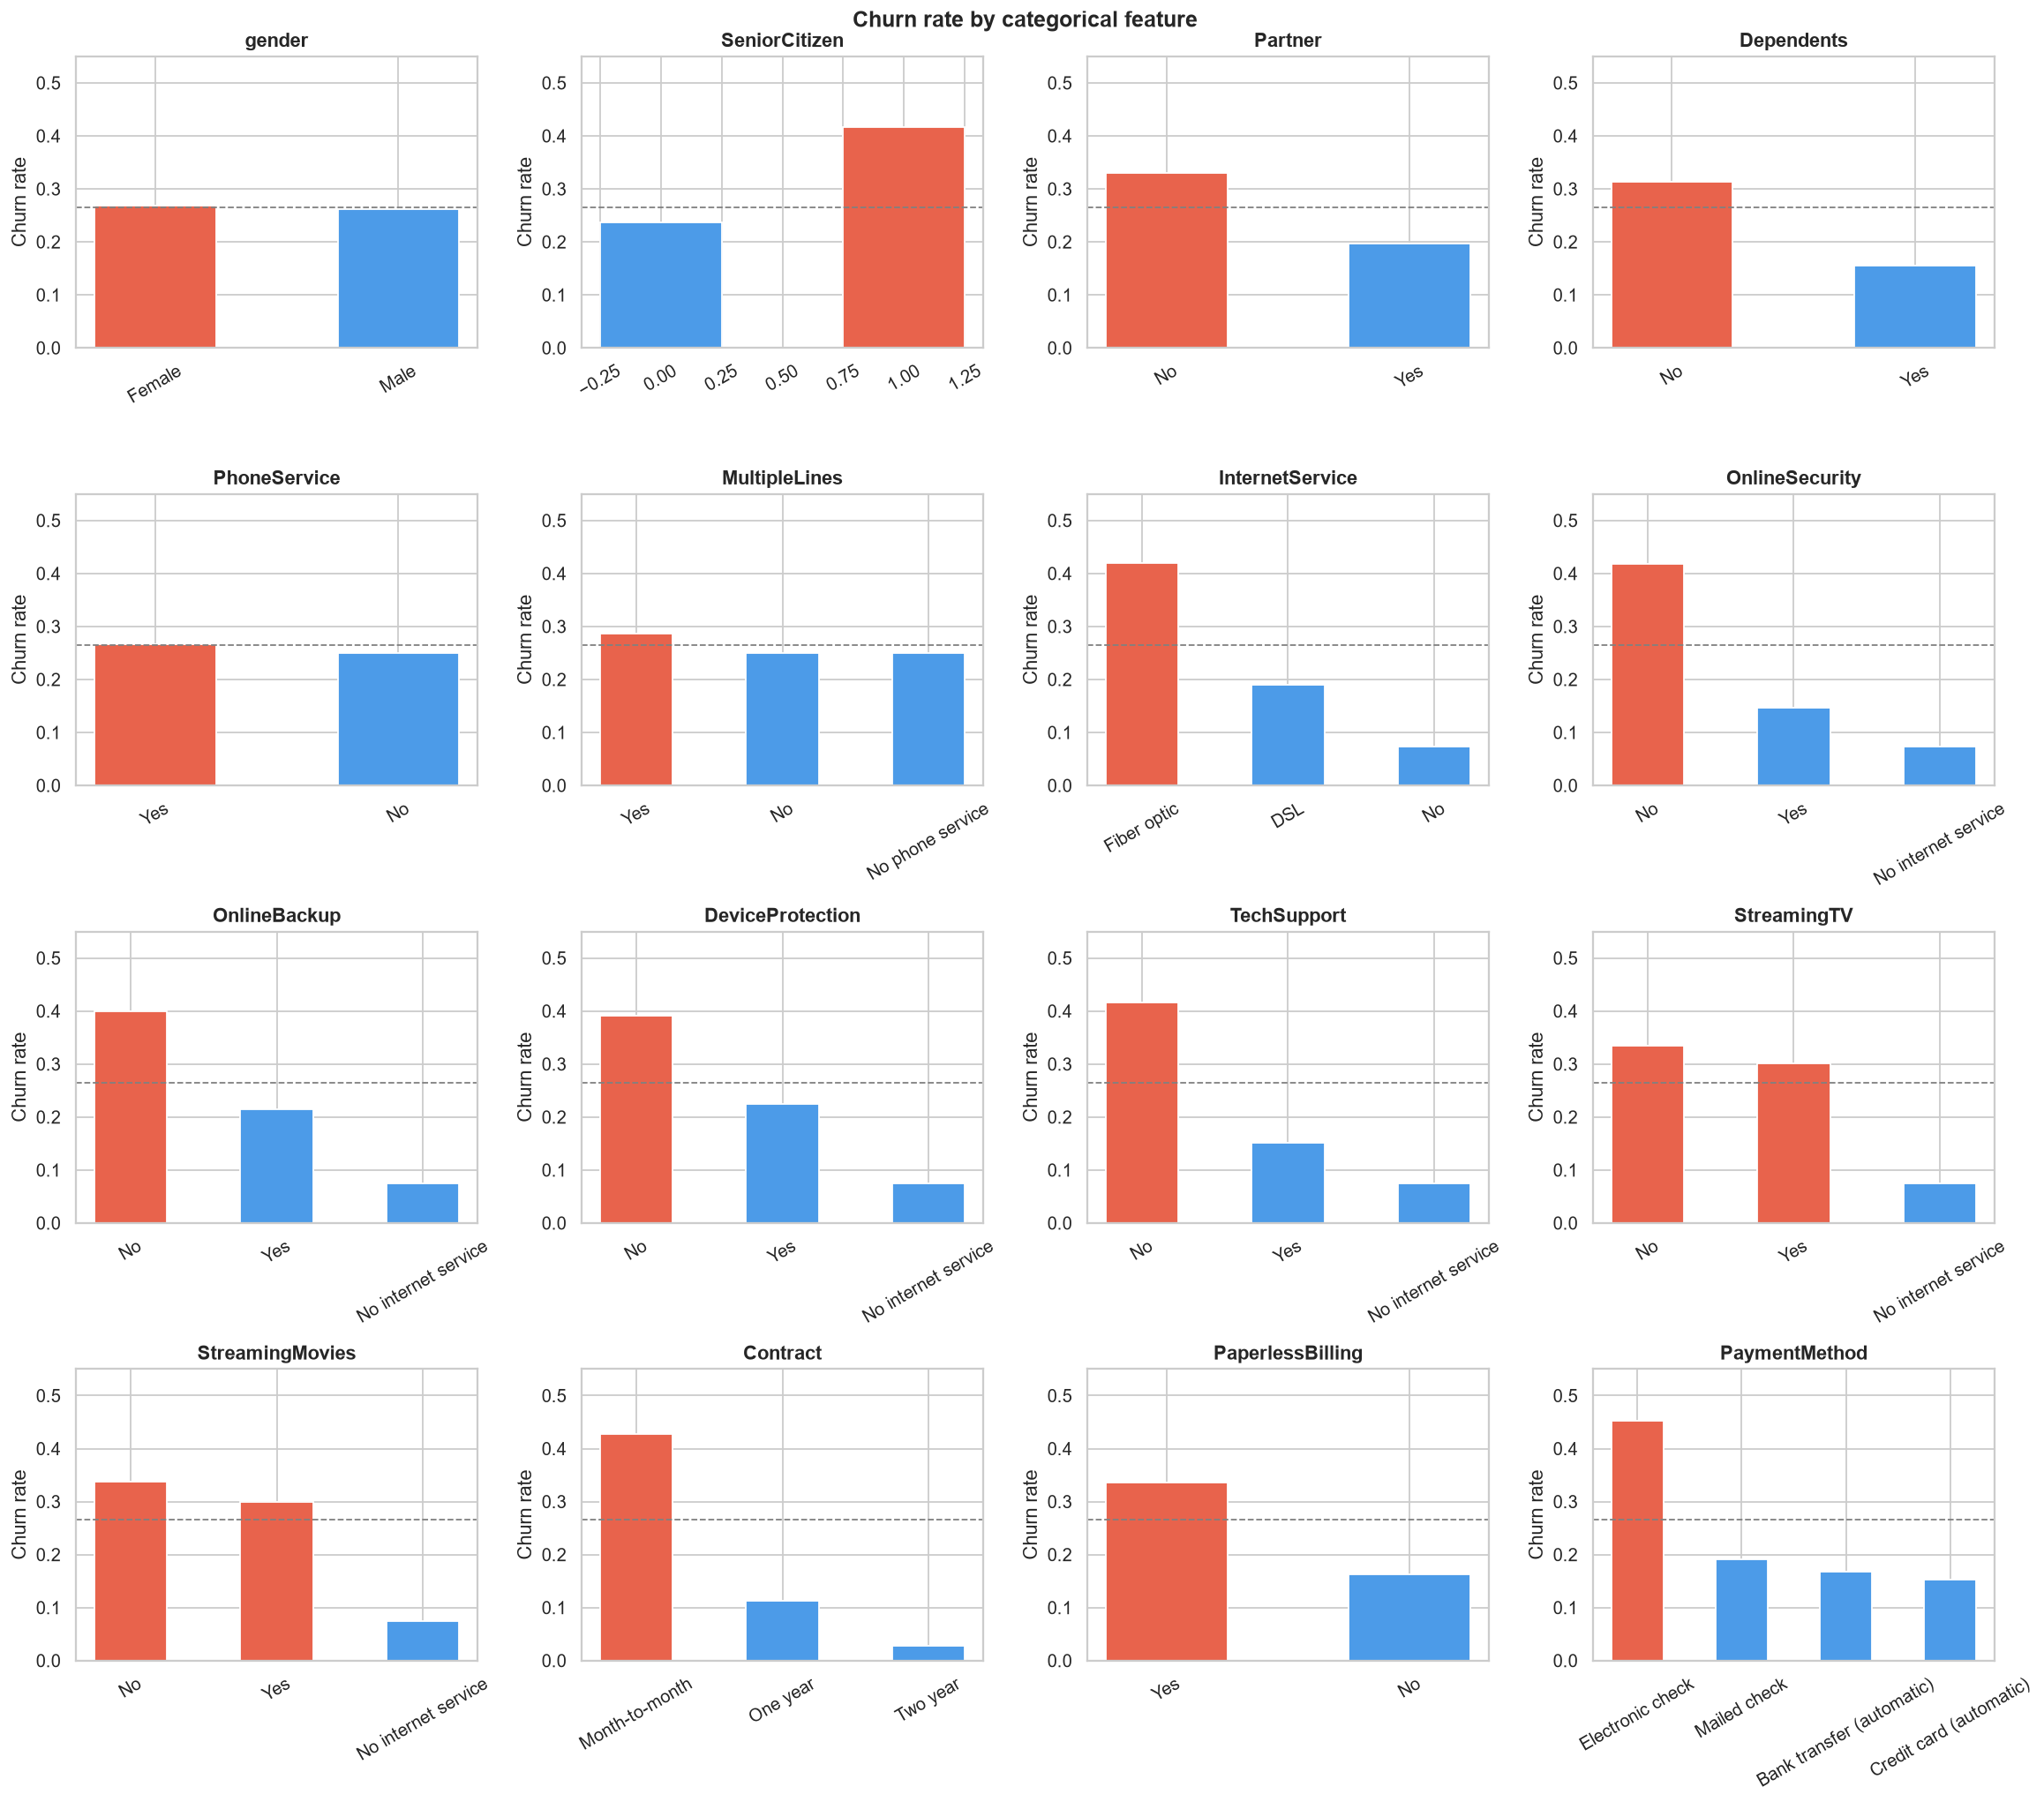

In [5]:
cat_cols = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod'
]

fig, axes = plt.subplots(4, 4, figsize=(18, 16))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    churn_by_cat = df.groupby(col)['Churn'].mean().sort_values(ascending=False)
    colors = ['#E8634C' if v > df['Churn'].mean() else '#4C9BE8'
              for v in churn_by_cat.values]
    axes[i].bar(churn_by_cat.index, churn_by_cat.values, color=colors, width=0.5)
    axes[i].axhline(df['Churn'].mean(), color='gray', linestyle='--',
                    linewidth=1, label='Avg churn')
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_ylabel('Churn rate')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].set_ylim(0, 0.55)

plt.suptitle('Churn rate by categorical feature', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/03_categorical_churn_rates.png', bbox_inches='tight')
plt.show()

### Key Findings

- **Contract type** is the strongest predictor:
  - Month-to-month customers churn at about **43%**
  - Two-year contract customers churn at about **3%**

- **Internet service matters**:
  - **Fibre optic** users churn more than **DSL** users
  - Suggests possible pricing or satisfaction issues

- **Support-related features**:
  - Customers with **no online security** or **no tech support** churn significantly more

- **Payment method signal**:
  - **Electronic check** payments correlate with higher churn
  - May be a proxy for **less-engaged customers**


Top positive correlations with Churn:
gender_Male                      -0.008612
PhoneService_Yes                  0.011942
MultipleLines_Yes                 0.040102
StreamingMovies_Yes               0.061382
StreamingTV_Yes                   0.063228
SeniorCitizen                     0.150889
PaperlessBilling_Yes              0.191825
MonthlyCharges                    0.193356
PaymentMethod_Electronic check    0.301919
InternetService_Fiber optic       0.308020
Name: Churn, dtype: float64

Top negative correlations with Churn:
tenure                                 -0.352229
Contract_Two year                      -0.302253
OnlineSecurity_No internet service     -0.227890
OnlineBackup_No internet service       -0.227890
TechSupport_No internet service        -0.227890
StreamingMovies_No internet service    -0.227890
DeviceProtection_No internet service   -0.227890
InternetService_No                     -0.227890
StreamingTV_No internet service        -0.227890
TotalCharges           

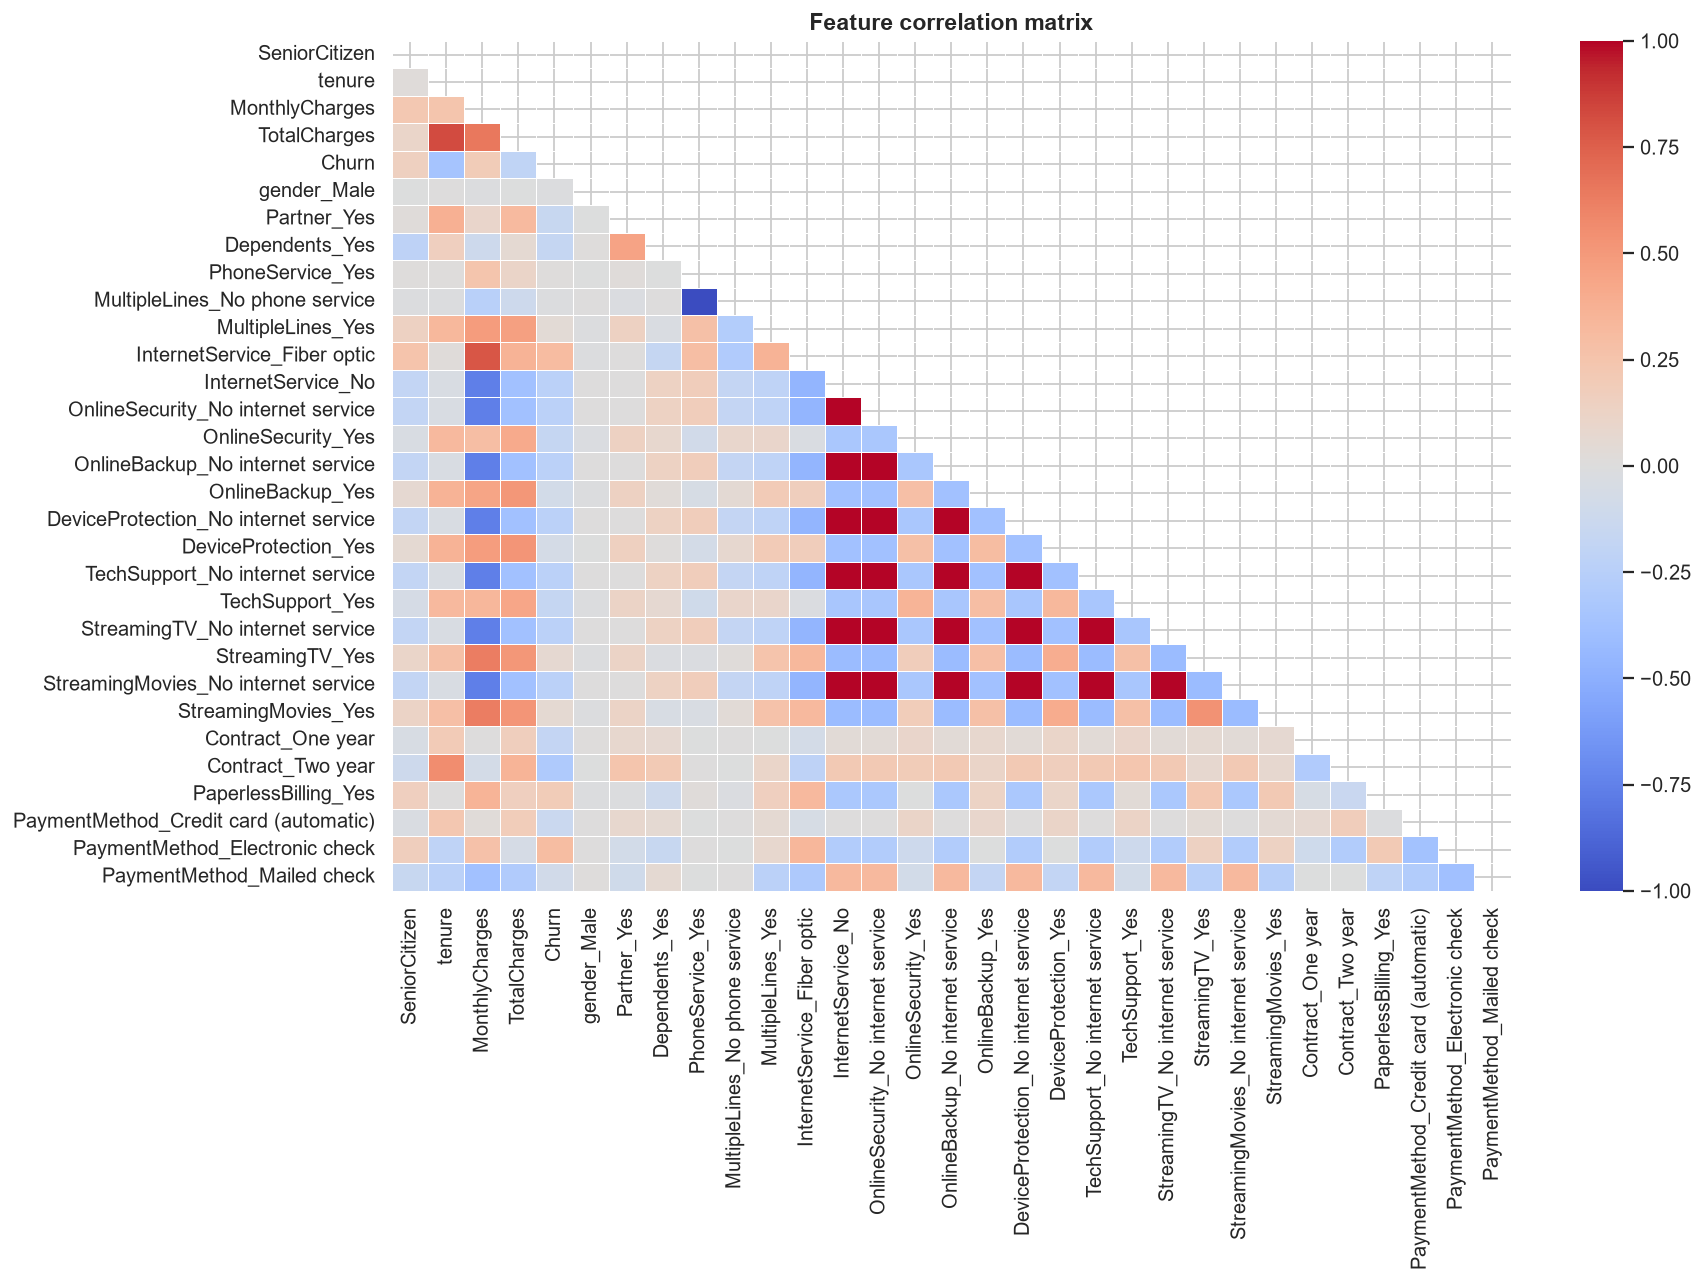

In [6]:
# Encode categoricals temporarily for correlation
df_encoded = pd.get_dummies(df, drop_first=True)

fig, ax = plt.subplots(figsize=(14, 10))

corr = df_encoded.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=False, cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=ax,
            linewidths=0.3, linecolor='white')

# Highlight churn correlations
churn_corr = df_encoded.corr()['Churn'].drop('Churn').sort_values()
print("\nTop positive correlations with Churn:")
print(churn_corr.tail(10))
print("\nTop negative correlations with Churn:")
print(churn_corr.head(10))

ax.set_title('Feature correlation matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/04_correlation_heatmap.png', bbox_inches='tight')
plt.show()

## Key EDA findings

| Finding | Implication for modelling |
|---|---|
| 26.5% churn rate — moderate imbalance | Use ROC-AUC / F1, apply SMOTE |
| Tenure strongly negatively correlated with churn | Engineer "early customer" flag (tenure < 12 months) |
| Month-to-month contracts → 43% churn | Contract type will be top feature |
| High monthly charges → higher churn risk | MonthlyCharges is a key numerical feature |
| Fibre optic users churn more | InternetService_Fiber will carry signal |
| TotalCharges ≈ tenure × MonthlyCharges | Risk of multicollinearity — monitor in Phase 3 |